## Code Explainer

In [5]:
import ast
import astor
from typing import List, Dict, Any, Tuple

class CodeAnalyzer(ast.NodeVisitor):
    """
    Analyzes a Python code snippet using AST to extract structural features.
    """
    def __init__(self):
        self.functions: List[str] = []
        self.classes: List[str] = []
        self.imports: List[str] = []
        self.patterns: Dict[str, int] = {'loops': 0, 'conditionals': 0}

    def visit_FunctionDef(self, node):
        """Called for function definitions (def)."""
        self.functions.append(node.name)
        self.generic_visit(node)     # Continue traversing inside the function

    def visit_ClassDef(self, node):
        """Called for class definitions (class)."""
        self.classes.append(node.name)
        self.generic_visit(node)       # Continue traversing inside the class

    def visit_Import(self, node):
        """Called for simple imports (import os)."""
        for alias in node.names:
            self.imports.append(alias.name)

    def visit_ImportFrom(self, node):
        """Called for 'from X import Y' imports."""
        self.imports.append(f"{node.module}")     # Store the module name

    def visit_For(self, node):
        """Called for 'for' loops."""
        self.patterns['loops'] += 1
        self.generic_visit(node)

    def visit_While(self, node):
        """Called for 'while' loops."""
        self.patterns['loops'] += 1
        self.generic_visit(node)

    def visit_If(self, node):
        """Called for 'if/elif/else' statements."""
        # Note: A single 'If' node covers the whole if/elif/else block structure.

        self.patterns['conditionals'] += 1 
        self.generic_visit(node)


def parse_code_snippet(code: str) -> Dict[str, Any]:
    """
    Main function to parse a code string and return extracted features.
    """
    try:
        # 1. Parse the code into an Abstract Syntax Tree
        tree = ast.parse(code)
        
        # 2. Extract features using the custom visitor
        analyzer = CodeAnalyzer()
        analyzer.visit(tree)
        
        # 3. Use astor to reconstruct a normalized version (optional but useful)
        # This can help in checking the AST's interpretation
        normalized_code = astor.to_source(tree).strip() 
        
        return {
            'code': code,
            'normalized_code': normalized_code,
            'functions': analyzer.functions,
            'classes': analyzer.classes,
            'imports': analyzer.imports,
            'patterns': analyzer.patterns,
        }
    except SyntaxError as e:
        print(f"Syntax Error in code snippet: {e}")
        return {'code': code, 'error': str(e), 'functions': [], 'classes': [], 'imports': [], 'patterns': {}}

In [6]:
# model_manager.py

from transformers import AutoModel, AutoTokenizer
import torch
from typing import List, Dict, Any, Tuple

# Pretrained models to use
MODEL_NAMES = {
    'MiniLM': 'microsoft/MiniLM-L12-H384-uncased',
    'DistilRoBERTa': 'distilroberta-base',
    'MPNet': 'microsoft/mpnet-base',
}

def load_models_and_tokenizers() -> Dict[str, Tuple[Any, Any]]:
    """Loads all specified models and their corresponding tokenizers."""
    loaded_models = {}
    print("Loading models and tokenizers...")
    for name, model_path in MODEL_NAMES.items():     # AutoTokenizer handles the model-specific tokenization rules
        
        tokenizer = AutoTokenizer.from_pretrained(model_path)     # AutoModel loads the base model (without classification head)
    
        model = AutoModel.from_pretrained(model_path)
        loaded_models[name] = (model, tokenizer)
        print(f"  ✅ Loaded {name}")
    return loaded_models


def get_model_embeddings(
    code_snippet: str, 
    loaded_models: Dict[str, Tuple[Any, Any]]
) -> Dict[str, Any]:
    """
    Tokenizes a code snippet and generates embeddings for all models.
    """
    results = {}
    for name, (model, tokenizer) in loaded_models.items():
        # 1. Tokenize the code
        inputs = tokenizer(
            code_snippet, 
            return_tensors="pt", 
            padding=True, 
            truncation=True
        )
        
        # 2. Extract token list (for later visualization of tokens)
        token_list = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

        # 3. Generate embeddings
        with torch.no_grad():
            outputs = model(**inputs)
        
        # Get the [CLS] token embedding (representing the entire sequence)
        # outputs[0] is the last hidden state: (batch_size, sequence_length, hidden_size)
        cls_embedding = outputs.last_hidden_state[:, 0, :].squeeze().cpu().numpy()
        
        results[name] = {
            'token_ids': inputs['input_ids'].tolist(),
            'tokens': token_list,
            'embedding': cls_embedding, # numpy array of the sequence embedding
            'embedding_size': cls_embedding.shape[0]
        }
    return results

In [7]:
# visualization.py

import numpy as np
import matplotlib.pyplot as plt
from typing import List, Dict, Any
from sklearn.metrics.pairwise import cosine_similarity
import itertools

def visualize_embedding_similarity(all_embeddings: Dict[str, Dict[str, np.ndarray]]):
    """
    Calculates and plots the Cosine Similarity matrix between the embeddings
    of different models for the same code snippet.
    
    Args:
        all_embeddings: A dictionary where keys are model names and values 
                        are dictionaries containing 'embedding' (numpy array).
    """
    model_names = list(all_embeddings.keys())
    embeddings_list = [v['embedding'] for v in all_embeddings.values()]

    if len(embeddings_list) < 2:
        print("Error: Need at least two embeddings to calculate similarity.")
        return

    # --- START OF MODIFICATION: Prepare for Similarity Calculation ---
    
    # 1. Ensure all embeddings are the same size using padding/truncation
    
    # Find the largest dimension (e.g., 768)
    max_dim = max(e.shape[0] for e in embeddings_list) 
    
    X_uniform = []
    for embed in embeddings_list:
        if embed.ndim > 1:
            embed = embed.flatten()

        current_dim = embed.shape[0]

        if current_dim > max_dim:
            # Truncate
            X_uniform.append(embed[:max_dim])
        elif current_dim < max_dim:
            # Pad with zeros to match the largest dimension
            padding = np.zeros(max_dim - current_dim)
            X_uniform.append(np.concatenate((embed, padding)))
        else:
            # Correct size
            X_uniform.append(embed)

    # Stack the uniformly sized embeddings into matrix X (rows = models, columns = dimension)
    X = np.vstack(X_uniform)
    
    # 2. Calculate the Cosine Similarity matrix (X.T is transpose, which is not needed here)
    # The cosine_similarity function handles the matrix X directly.
    similarity_matrix = cosine_similarity(X)
    
    # --- END OF MODIFICATION ---

    # 3. Plotting the Heatmap
    plt.figure(figsize=(10, 8))
    
    # Create the heatmap
    img = plt.imshow(similarity_matrix, cmap='viridis', vmin=0.0, vmax=1.0)
    
    # Add color bar
    plt.colorbar(img, label='Cosine Similarity')
    
    # Set ticks and labels for the axes
    plt.xticks(np.arange(len(model_names)), model_names, rotation=45, ha="right")
    plt.yticks(np.arange(len(model_names)), model_names)

    # Add text annotations for similarity values
    for i in range(len(model_names)):
        for j in range(len(model_names)):
            plt.text(j, i, f'{similarity_matrix[i, j]:.3f}', 
                     ha="center", va="center", color="w", fontsize=10)

    plt.title('Cosine Similarity of Embeddings Across Different Models')
    plt.xlabel('Model')
    plt.ylabel('Model')
    plt.tight_layout()
    plt.show()


def visualize_feature_comparison(all_features: List[Dict[str, Any]]):
    """
    Creates a bar chart to compare the extracted structural features across snippets.
    
    Args:
        all_features: List of dictionaries from `parse_code_snippet`.
    """
    # Sum up feature counts across all snippets
    total_functions = sum(len(f['functions']) for f in all_features)
    total_classes = sum(len(f['classes']) for f in all_features)
    total_imports = sum(len(f['imports']) for f in all_features)
    total_loops = sum(f['patterns'].get('loops', 0) for f in all_features)
    total_conditionals = sum(f['patterns'].get('conditionals', 0) for f in all_features)
    
    feature_names = ['Functions', 'Classes', 'Imports', 'Loops', 'Conditionals']
    counts = [total_functions, total_classes, total_imports, total_loops, total_conditionals]

    plt.figure(figsize=(10, 6))
    bars = plt.bar(feature_names, counts, color=['#4CAF50', '#2196F3', '#FFC107', '#E91E63', '#9C27B0'])
    
    # Add counts on top of bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.5, int(yval), ha='center', va='bottom', fontsize=10)

    plt.title(f'Aggregated Code Structure Features (N={len(all_features)} Snippets)')
    plt.ylabel('Total Count')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


STEP 2: AST Parsing and Feature Extraction

--- Snippet 1 Summary ---
Functions: ['calculate_area']
Classes: []
Imports: []
Patterns: {'loops': 0, 'conditionals': 1}

--- Snippet 2 Summary ---
Functions: ['__init__', 'process']
Classes: ['DataProcessor']
Imports: ['os', 'math']
Patterns: {'loops': 1, 'conditionals': 0}

--- Snippet 3 Summary ---
Functions: ['quick_sort']
Classes: []
Imports: []
Patterns: {'loops': 0, 'conditionals': 1}

--- Snippet 4 Summary ---
Functions: ['fetch_data']
Classes: []
Imports: ['requests']
Patterns: {'loops': 0, 'conditionals': 0}

--- Snippet 5 Summary ---
Functions: []
Classes: []
Imports: []
Patterns: {'loops': 0, 'conditionals': 2}

--- Snippet 6 Summary ---
Functions: ['count_to_ten']
Classes: []
Imports: []
Patterns: {'loops': 1, 'conditionals': 0}

--- Snippet 7 Summary ---
Functions: []
Classes: ['Empty']
Imports: []
Patterns: {'loops': 0, 'conditionals': 0}

--- Snippet 8 Summary ---
Functions: []
Classes: []
Imports: ['collections']
Patterns: 

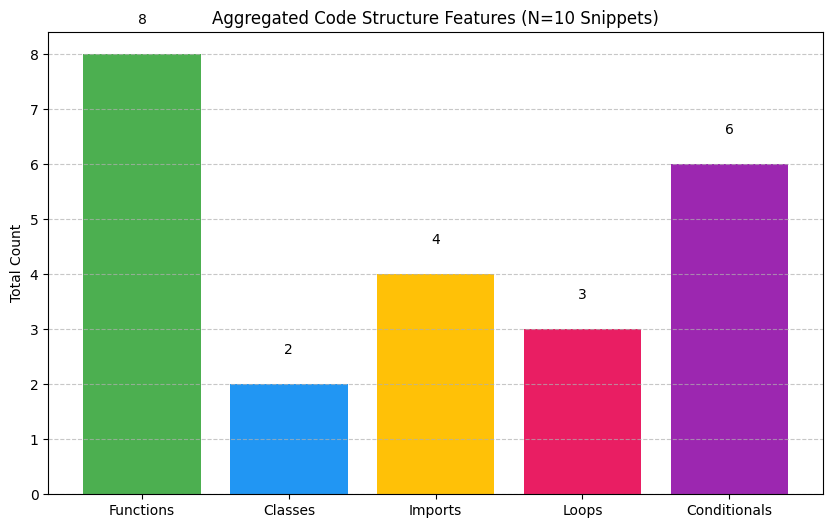


STEP 4: Model Loading and Embedding Generation
Loading models and tokenizers...
  ✅ Loaded MiniLM
  ✅ Loaded DistilRoBERTa


Some weights of MPNetModel were not initialized from the model checkpoint at microsoft/mpnet-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


  ✅ Loaded MPNet

STEP 5: Model Comparison: Tokens and Embedding Size

--- Model: MiniLM ---
Embedding Size (Hidden Dim): 384
Token Count: 34
Sample Tokens: ['[CLS]', 'def', 'calculate', '_', 'area', '(', 'length', ',', 'width', ')']...

--- Model: DistilRoBERTa ---
Embedding Size (Hidden Dim): 768
Token Count: 55
Sample Tokens: ['<s>', 'Ċ', 'def', 'Ġcalculate', '_', 'area', '(', 'length', ',', 'Ġwidth']...

--- Model: MPNet ---
Embedding Size (Hidden Dim): 768
Token Count: 34
Sample Tokens: ['<s>', 'def', 'calculate', '_', 'area', '(', 'length', ',', 'width', ')']...

STEP 6: Embedding Visualization (PCA)


ValueError: all input arrays must have the same shape

In [8]:
# main_project.py

from code_parser import parse_code_snippet
from model_manager import load_models_and_tokenizers, get_model_embeddings
from visualization import visualize_embeddings_pca, visualize_feature_comparison
import numpy as np

# --- 1. Define the Code Snippets (Minimum 10) ---
CODE_SNIPPETS = [
    """
def calculate_area(length, width):
    # A simple function with a return
    if length > 0 and width > 0:
        return length * width
    return 0
""", # Snippet 1: Function, conditional, docstring (implicitly parsed)

    """
import os
import math

class DataProcessor:
    def __init__(self, data):
        self.data = data
        self.count = len(data)
    
    def process(self):
        for item in self.data:
            print(f"Processing: {item}")
        return self.count * math.pi
""",            # Snippet 2: Imports, class, function, loop

    """
def quick_sort(arr):
    if len(arr) <= 1:
        return arr
    pivot = arr[len(arr) // 2]
    left = [x for x in arr if x < pivot]
    middle = [x for x in arr if x == pivot]
    right = [x for x in arr if x > pivot]
    return quick_sort(left) + middle + quick_sort(right)
""",        # Snippet 3: Recursion, list comprehensions (complex pattern)

    """
from requests import get

def fetch_data(url):
    try:
        response = get(url)
        return response.json()
    except Exception as e:
        print(f"Error: {e}")
        return None
""",     # Snippet 4: ImportFrom, try/except (error handling pattern)

    """
x = 10
if x > 5:
    y = x * 2
elif x == 5:
    y = x + 1
else:
    y = x
""",        # Snippet 5: Only conditionals, no functions/classes/imports

    """
def count_to_ten():
    i = 0
    while i < 10:
        print(i)
        i += 1
""",        # Snippet 6: Function and a while loop

    """
class Empty:
    pass
""", # Snippet 7: Minimal class

    """
import collections
x = collections.defaultdict(list)
""", # Snippet 8: Simple import and usage

    """
def get_message(is_admin):
    message = ""
    if is_admin:
        message = "Admin access granted"
    else:
        message = "User access granted"
    return message
""", # Snippet 9: Simple function with an IF-ELSE block

    """
def sum_list(data_list):
    total = 0
    for item in data_list:
        total += item
    return total

# Main execution block
if __name__ == '__main__':
    data = [1, 2, 3, 4]
    result = sum_list(data)
""", # Snippet 10: Function, loop, and main execution boilerplate
]

def main():
    # --- 2. Code Parsing and Feature Extraction ---
    print("\n" + "="*50)
    print("STEP 2: AST Parsing and Feature Extraction")
    print("="*50)
    
    all_parsed_features = []
    for i, code in enumerate(CODE_SNIPPETS):
        features = parse_code_snippet(code)
        all_parsed_features.append(features)
        print(f"\n--- Snippet {i+1} Summary ---")
        print(f"Functions: {features.get('functions', 'N/A')}")
        print(f"Classes: {features.get('classes', 'N/A')}")
        print(f"Imports: {features.get('imports', 'N/A')}")
        print(f"Patterns: {features.get('patterns', 'N/A')}")

    # --- 3. Aggregate Feature Visualization ---
    print("\n" + "="*50)
    print("STEP 3: Aggregated Feature Visualization")
    print("="*50)
    visualize_feature_comparison(all_parsed_features)


    # --- 4. Model Loading and Embedding Generation ---
    print("\n" + "="*50)
    print("STEP 4: Model Loading and Embedding Generation")
    print("="*50)
    loaded_models = load_models_and_tokenizers()
    
    # We'll use the first snippet for a detailed embedding comparison visualization
    target_snippet = CODE_SNIPPETS[0] 
    
    # Get embeddings for the target snippet from all models
    model_outputs = get_model_embeddings(target_snippet, loaded_models)
    
    # --- 5. Output Comparison (Tokenization and Embedding Size) ---
    print("\n" + "="*50)
    print("STEP 5: Model Comparison: Tokens and Embedding Size")
    print("="*50)

    for model_name, data in model_outputs.items():
        print(f"\n--- Model: {model_name} ---")
        print(f"Embedding Size (Hidden Dim): {data['embedding_size']}")
        print(f"Token Count: {len(data['tokens'])}")
        # Print a sample of tokens to show tokenizer differences
        print(f"Sample Tokens: {data['tokens'][:10]}...") 


    # --- 6. Embedding Visualization (PCA) ---
    print("\n" + "="*50)
    print("STEP 6: Embedding Visualization (PCA)")
    print("="*50)
    # The PCA visualization compares the vector space positions for the *same* snippet
    # across *different* models.
    visualize_embeddings_pca(model_outputs)
    
    print("\nProject execution complete. Check the generated plots.")

# Here we will Call main directly in the notebook
main()